# 02 — The corn–soybean pair: cointegration and classical mean-reversion strategies

The starting point of the project (Chan, *Algorithmic Trading*, Ch. 2–3): if corn and soybean prices are
cointegrated, a suitably hedged spread is stationary, and we can buy it when it is unusually low and sell it
when it is unusually high.

1. **Tests** (training sample only): unit roots, Engle–Granger in both orderings, Johansen, error-correction model and half-life.
2. **Strategy A — price levels, rolling OLS hedge.** Hedge ratio from a 252-day rolling regression of soybean on corn; z-score over 252 days.
3. **Strategy B — log prices, three hedge estimators.** Static Johansen vector, a Kalman-filtered hedge ratio, and a rolling Johansen vector; z-score window equal to the half-life.

All strategies use the same rules (`src/backtest.py`): enter when |z| exceeds a threshold, exit when z crosses 0, freeze the hedge at entry, returns = P&L / gross capital at entry. **Every parameter is chosen on the training sample (first 70%) and evaluated once on the test sample.**

*Data: front-month futures 2005–2026 (notebook 01). These contain artificial roll jumps — treat the results as indicative.*

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_futures, train_test_split_date, save_figure, save_table
from src.cointegration import (adf_table, engle_granger, johansen_test, half_life, ecm,
                               rolling_ols, rolling_johansen, kalman_regression)
from src.backtest import (rolling_zscore, log_to_units, zscore_strategy,
                          split_performance)

prices = load_futures()                      # columns: corn, soybean (cents / bushel)
logp = np.log(prices)
TEST_START = train_test_split_date(prices.index, train_frac=0.7)
train = prices.index < TEST_START
print(f'Train: {prices.index[0].date()} to {prices.index[train][-1].date()} ({train.sum()} days)')
print(f'Test:  {TEST_START.date()} to {prices.index[-1].date()} ({(~train).sum()} days)')

Train: 2005-01-03 to 2019-10-03 (3712 days)
Test:  2019-10-04 to 2026-02-02 (1591 days)


## 1. Is the pair cointegrated? (training sample)

Both prices are I(1): the ADF test does not reject a unit root in levels but strongly rejects it in first differences.

In [2]:
pd.concat({'price': adf_table(prices[train]), 'log price': adf_table(logp[train])}).round(4)

ADF (level)  p (level)  ADF (diff)  p (diff)
price     corn         -2.0511     0.2646    -13.2655       0.0
          soybean      -2.4233     0.1353    -12.5275       0.0
log price corn         -2.4192     0.1364    -12.3458       0.0
          soybean      -2.6538     0.0824    -12.4656       0.0

**Engle–Granger (CADF).** Regress one price on the other and test the residual for a unit root, in both orderings
(Chan, Example 2.6). P-values use the MacKinnon critical values for residual-based tests. We follow Chan and take the
ordering with the more negative statistic as the dependent variable.

In [3]:
eg = pd.DataFrame([engle_granger(prices['soybean'][train], prices['corn'][train]),
                   engle_granger(prices['corn'][train], prices['soybean'][train])]).set_index('dependent')
eg.round(4)

,beta,alpha,t-stat,p-value
dependent,,,,
soybean,1.6645,328.2656,-2.8818,0.1410
corn,0.4669,-58.2693,-2.6881,0.2039


**Johansen test** on log prices (order-independent; Chan, Example 2.7). The first eigenvector, normalised on soybean,
gives the static log hedge ratio used by strategy B.

In [4]:
johansen, evec = johansen_test(logp.loc[train, ['soybean', 'corn']])
vec = evec[:, 0] / evec[0, 0]                       # soybean coefficient = 1
BETA_LOG = -vec[1]                                  # log soy = alpha + beta * log corn
ALPHA_LOG = (logp['soybean'] - BETA_LOG * logp['corn'])[train].mean()
print(f'Static Johansen spread: log(soy) - {BETA_LOG:.3f} log(corn) - {ALPHA_LOG:.3f}')
johansen.round(2)

Static Johansen spread: log(soy) - 0.765 log(corn) - 2.319


,trace,trace 95%,trace 99%,max-eig,max-eig 95%
r<=0,25.07,15.49,19.93,18.99,14.26
r<=1,6.08,3.84,6.63,6.08,3.84


**Speed of mean reversion.** The half-life follows from $\Delta s_t = c + \lambda s_{t-1} + \varepsilon_t$ as
$-\ln 2/\lambda$. The error-correction model $\Delta \log S_t = c + \gamma s_{t-1} + \delta\, \Delta \log C_t$ asks whether
soybean itself is pulled back towards the long-run relation ($\gamma<0$).

In [5]:
eg_soy = eg.loc['soybean']
spread_price = prices['soybean'] - eg_soy['beta'] * prices['corn'] - eg_soy['alpha']
spread_log = logp['soybean'] - BETA_LOG * logp['corn'] - ALPHA_LOG

HALF_LIFE_LOG = half_life(spread_log[train])
tests = pd.DataFrame({
    'half-life (days)': [half_life(spread_price[train]), HALF_LIFE_LOG],
    'ECM gamma': [np.nan, ecm(logp['soybean'][train], logp['corn'][train], spread_log[train])['gamma']],
    'ECM p-value': [np.nan, ecm(logp['soybean'][train], logp['corn'][train], spread_log[train])['p-value']],
}, index=['price-level spread (EG)', 'log spread (Johansen)'])
tests.round(4)

,half-life (days),ECM gamma,ECM p-value
price-level spread (EG),84.1026,NaN,NaN
log spread (Johansen),98.0730,-0.0076,0.0


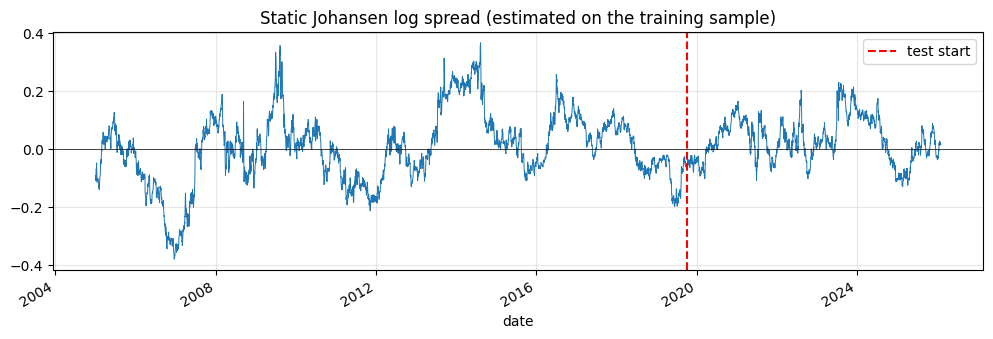

In [6]:
fig, ax = plt.subplots(figsize=(12, 3.5))
spread_log.plot(ax=ax, lw=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(TEST_START, color='r', ls='--', label='test start')
ax.set_title('Static Johansen log spread (estimated on the training sample)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

The evidence for cointegration is **weaker than it first looked**. With the correct residual-based critical values the
Engle–Granger test does *not* reject "no cointegration" at 5% for price levels (in the first version of the project
plain ADF p-values were used, which gave p ≈ 0.003). The Johansen test on log prices does reject at 1%, and the ECM
coefficient is negative and significant, but reversion is slow — a half-life of 3–4 months — and after the training
sample the static spread drifts away from zero. This is why all strategies below use rolling z-scores, and most use
time-varying hedge ratios.

## 2. Strategy A — price levels, rolling OLS hedge ratio

Hedge ratio $\beta_t$ and intercept from a regression of soybean on corn over the previous 252 days; spread
$s_t = S_t - \alpha_t - \beta_t C_t$; z-score relative to the previous 252 days. A 252-day window was preferred to the
half-life because shorter windows produced unstable (even negative) hedge ratios, e.g. in the 2012 drought.

In [7]:
LOOKBACK = 252
ENTRY_GRID = [1.0, 1.5, 2.0, 2.5, 3.0]

coef = rolling_ols(prices['soybean'], prices['corn'], LOOKBACK)
spread_A = prices['soybean'] - coef['alpha'] - coef['beta'] * prices['corn']
z_A = rolling_zscore(spread_A, LOOKBACK)
units_A = pd.DataFrame({'corn': -coef['beta'], 'soybean': 1.0})     # units per unit of spread

grid_A = pd.DataFrame({e: split_performance(*zscore_strategy(prices, units_A, z_A, e), TEST_START).loc['train']
                       for e in ENTRY_GRID}).T
ENTRY_A = grid_A['Sharpe'].idxmax()
print(f'Entry threshold chosen on the training sample: {ENTRY_A}')
grid_A[['Sharpe', 'Ann. return', 'Max drawdown', 'Trades']].round(3)

Entry threshold chosen on the training sample: 3.0


,Sharpe,Ann. return,Max drawdown,Trades
1.0,-0.130,-0.017,-0.497,30.0
1.5,-0.167,-0.020,-0.509,25.0
2.0,-0.189,-0.019,-0.428,15.0
2.5,-0.175,-0.015,-0.385,10.0
3.0,-0.009,-0.001,-0.229,7.0


In [8]:
ret_A, pos_A = zscore_strategy(prices, units_A, z_A, ENTRY_A)
split_performance(ret_A, pos_A, TEST_START).round(3)

,Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,In market,Trades
train,-0.009,-0.001,0.074,-0.041,-0.229,0.215,7.0
test,-0.273,-0.013,0.049,-0.087,-0.241,0.071,3.0


## 3. Strategy B — log prices, three hedge-ratio estimators

The log spread $s_t = \log S_t - \beta_t \log C_t - \alpha_t$ behaves like a portfolio holding \$1 of soybean and
\$$\beta_t$ short of corn, so positions are converted to units with `log_to_units` (weights / price) and then frozen
at entry. The z-score window is the half-life of the static spread. We compare

* **B1 static** — the Johansen vector estimated on the training sample;
* **B2 Kalman** — $\log S_t = \beta_t \log C_t + \alpha_t + \varepsilon_t$ with random-walk coefficients (Chan, Ch. 3), tuned over the state-noise $\delta$ and observation variance;
* **B3 rolling Johansen** — the Johansen vector re-estimated on a rolling window; trades are only allowed when yesterday's hedge ratio lies in $[-2, 2]$, because short windows produce explosive estimates.

The entry threshold is chosen on the static spread and reused for B2 and B3.

In [9]:
Z_WIN = int(round(HALF_LIFE_LOG))
print(f'z-score window = half-life = {Z_WIN} days')

def log_units(beta):
    """Units per unit of log spread for weights (soybean: 1, corn: -beta)."""
    return log_to_units(pd.DataFrame({'corn': -beta, 'soybean': 1.0}, index=prices.index), prices)

# B1: static Johansen
z_B1 = rolling_zscore(spread_log, Z_WIN)
units_B1 = log_units(pd.Series(BETA_LOG, index=prices.index))
grid_B1 = pd.DataFrame({e: split_performance(*zscore_strategy(prices, units_B1, z_B1, e), TEST_START).loc['train']
                        for e in ENTRY_GRID}).T
ENTRY_B = grid_B1['Sharpe'].idxmax()
print(f'Entry threshold chosen on the training sample: {ENTRY_B}')
grid_B1[['Sharpe', 'Ann. return', 'Max drawdown', 'Trades']].round(3)

z-score window = half-life = 98 days
Entry threshold chosen on the training sample: 1.0


,Sharpe,Ann. return,Max drawdown,Trades
1.0,0.161,0.020,-0.379,73.0
1.5,0.050,0.006,-0.392,52.0
2.0,-0.067,-0.008,-0.364,36.0
2.5,-0.081,-0.009,-0.323,26.0
3.0,0.059,0.006,-0.302,20.0


In [10]:
# B2: Kalman filter, initialised at the training-sample OLS coefficients
ols_log = engle_granger(logp['soybean'][train], logp['corn'][train])
X_kf = pd.DataFrame({'corn': logp['corn'], 'const': 1.0})

def kalman_spread(delta, obs_cov):
    b = kalman_regression(logp['soybean'], X_kf, delta=delta, obs_cov=obs_cov,
                          state_init=[ols_log['beta'], ols_log['alpha']])
    return logp['soybean'] - b['corn'] * logp['corn'] - b['const'], b['corn']

rows = []
for delta in [1e-7, 1e-6, 1e-5, 1e-4]:
    for obs_cov in [1e-3, 1e-2, 1e-1, 1.0]:
        spread, beta = kalman_spread(delta, obs_cov)
        perf = split_performance(*zscore_strategy(prices, log_units(beta), rolling_zscore(spread, Z_WIN), ENTRY_B),
                                 TEST_START).loc['train']
        rows.append({'delta': delta, 'obs_cov': obs_cov, **perf})
grid_B2 = pd.DataFrame(rows).sort_values('Sharpe', ascending=False)
DELTA, OBS_COV = grid_B2.iloc[0][['delta', 'obs_cov']]
print(f'Chosen on training sample: delta={DELTA:.0e}, obs_cov={OBS_COV}')
grid_B2.head(5)[['delta', 'obs_cov', 'Sharpe', 'Ann. return', 'Trades']].round(3).astype({'delta': str})

Chosen on training sample: delta=1e-07, obs_cov=0.001


,delta,obs_cov,Sharpe,Ann. return,Trades
0,0.0,0.001,0.637,0.074,149.0
5,0.0,0.010,0.616,0.071,148.0
15,0.0,1.000,0.607,0.068,146.0
10,0.0,0.100,0.571,0.064,146.0
4,0.0,0.001,0.433,0.047,267.0


In [11]:
# B3: rolling Johansen (hedge vector normalised on soybean)
def rolling_johansen_spread(window):
    w = rolling_johansen(logp[['soybean', 'corn']], window=window, normalize_on='soybean')
    alpha = (w * logp.rolling(window).mean().shift(1)).sum(axis=1, min_count=2)   # window mean of the combination
    spread = (w * logp).sum(axis=1, min_count=2) - alpha
    return spread, -w['corn']

rows, rolling = [], {}
for window in [63, 98, 126, 196, 252, 392]:
    spread, beta = rolling_johansen_spread(window)
    rolling[window] = (spread, beta)
    allowed = (beta.abs() <= 2).shift(1)
    perf = split_performance(*zscore_strategy(prices, log_units(beta), rolling_zscore(spread, Z_WIN),
                                              ENTRY_B, allowed=allowed), TEST_START).loc['train']
    rows.append({'window': window, **perf})
grid_B3 = pd.DataFrame(rows).sort_values('Sharpe', ascending=False)
WINDOW_B3 = int(grid_B3.iloc[0]['window'])
print(f'Rolling window chosen on training sample: {WINDOW_B3}')
grid_B3[['window', 'Sharpe', 'Ann. return', 'Trades']].round(3)

Rolling window chosen on training sample: 126


,window,Sharpe,Ann. return,Trades
2,126,0.403,0.043,98.0
0,63,0.094,0.008,114.0
3,196,-0.035,-0.004,75.0
1,98,-0.090,-0.009,119.0
4,252,-0.101,-0.012,77.0
5,392,-0.245,-0.025,73.0


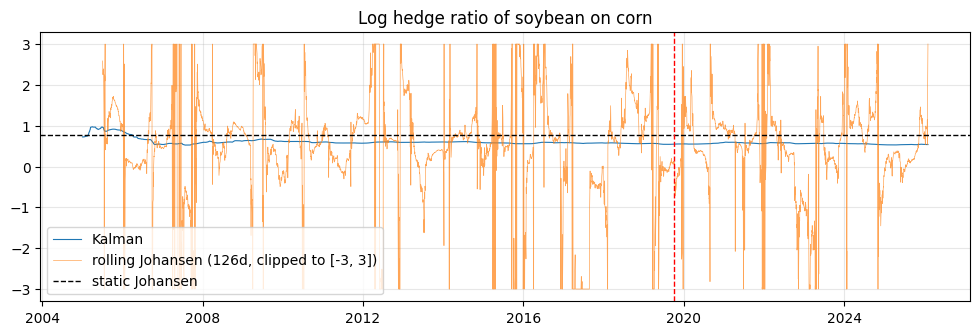

In [12]:
spread_B2, beta_B2 = kalman_spread(DELTA, OBS_COV)
spread_B3, beta_B3 = rolling[WINDOW_B3]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(beta_B2, lw=0.8, label='Kalman')
ax.plot(beta_B3.clip(-3, 3), lw=0.5, alpha=0.7, label=f'rolling Johansen ({WINDOW_B3}d, clipped to [-3, 3])')
ax.axhline(BETA_LOG, color='k', ls='--', lw=1, label='static Johansen')
ax.axvline(TEST_START, color='r', ls='--', lw=1)
ax.set_title('Log hedge ratio of soybean on corn'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 4. Out-of-sample comparison

In [13]:
strategies = {
    'A  price, rolling OLS':      zscore_strategy(prices, units_A, z_A, ENTRY_A),
    'B1 log, static Johansen':    zscore_strategy(prices, units_B1, z_B1, ENTRY_B),
    'B2 log, Kalman':             zscore_strategy(prices, log_units(beta_B2), rolling_zscore(spread_B2, Z_WIN), ENTRY_B),
    'B3 log, rolling Johansen':   zscore_strategy(prices, log_units(beta_B3), rolling_zscore(spread_B3, Z_WIN), ENTRY_B,
                                                  allowed=(beta_B3.abs() <= 2).shift(1)),
}

rows = {}
for name, (ret, pos) in strategies.items():
    perf = split_performance(ret, pos, TEST_START)
    rows[name] = {'train Sharpe': perf.loc['train', 'Sharpe'], 'test Sharpe': perf.loc['test', 'Sharpe'],
                  **{k: perf.loc['test', k] for k in ['Ann. return', 'Ann. vol', 'Total return', 'Max drawdown', 'Trades']}}
results = pd.DataFrame(rows).T
save_table(results, '02_pair_strategies')
results.round(3)

,train Sharpe,test Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,Trades
"A price, rolling OLS",-0.009,-0.273,-0.013,0.049,-0.087,-0.241,3.0
"B1 log, static Johansen",0.161,0.581,0.061,0.105,0.419,-0.137,33.0
"B2 log, Kalman",0.637,0.005,0.001,0.099,-0.027,-0.217,58.0
"B3 log, rolling Johansen",0.403,0.095,0.010,0.104,0.029,-0.204,58.0


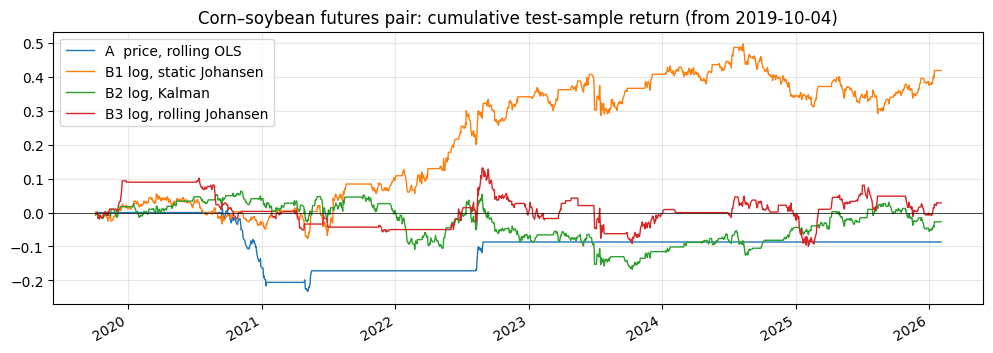

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, (ret, _) in strategies.items():
    ((1 + ret[~train]).cumprod() - 1).plot(ax=ax, lw=1, label=name)
ax.axhline(0, color='k', lw=0.5)
ax.set_title(f'Corn–soybean futures pair: cumulative test-sample return (from {TEST_START.date()})')
ax.set_xlabel('')
ax.legend(); ax.grid(alpha=0.3)
save_figure(fig, 'pair_test_returns')
plt.show()

**Take-aways.**
* Strategy A (price levels, rolling OLS) loses money in the training sample for *every* entry threshold once
  P&L is computed with the hedge frozen at entry; it also loses out of sample. (The first version selected the
  threshold on spread changes computed with a daily-updated hedge ratio, which are not tradeable P&L.)
* The most flexible estimator (B2, Kalman) has the best training Sharpe and the worst test Sharpe of the log
  strategies — a textbook case of fitting noise. The ranking of the specifications on the training sample does not
  carry over to the test sample.
* The static Johansen spread (B1) does best out of sample, but it had a training Sharpe of only 0.16. A test
  Sharpe of ~0.6 over six years with ~30 trades is roughly 1.5 standard errors from zero, and it is the best of
  four strategies — not evidence of a robust edge.
* In the first version the entry threshold and the rolling window were picked after looking at test-sample
  performance, and a log-price hedge ratio was applied to price *changes* (mixing units). Both are fixed here: all
  choices are made on the training sample and positions are sized consistently.